# MediciMess Charlie — Phase 1 Integrated Analysis

## 1. Objective

**Contributors:** Leigh, Hakeem, and Vijay

The objective of Phase 1 is to understand and validate the Medici Bank transaction dataset before developing the data pipeline. This notebook combines the team's three workstreams:

- **Leigh:** Dataset profiling, data-quality checks, and accounting validation
- **Hakeem:** Branch and transaction-type activity analysis
- **Vijay:** Time trends and florin-volume analysis

Together, these analyses describe the dataset's structure, quality, accounting integrity, operational activity, historical trends, and financial volume.

## 2. Dataset Preparation

Import the required libraries, locate `medici_transactions.csv`, load it into pandas, convert the transaction date, and derive the year. The path check allows the notebook to run from either the repository root or the `analysis` directory.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_CANDIDATES = [
    Path("medici_transactions.csv"),
    Path("../medici_transactions.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find medici_transactions.csv")

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year

print(f"Dataset: {DATA_PATH.resolve()}")
print(f"Rows: {df.shape[0]:,}")
print(f"Original columns: {df.shape[1] - 1}")
df.head()

Dataset: /Users/vijayarajan/Projects/MediciMess_Charlie/medici_transactions.csv
Rows: 80,230
Original columns: 13


,branch,counterparty,credit_account,credit_account_2,credit_amount,credit_amount_2,currency,date,debit_account,debit_amount,description,id,type,year
0,Florence,Republic of Florence,Cash,NaN,82833.66,NaN,florin,1390-01-01,Loans Receivable - Government,82833.66,Emergency war financing for Florence defense,1,war_financing,1390
1,Florence,Republic of Florence,Cash,NaN,124432.65,NaN,florin,1390-01-01,Loans Receivable - Government,124432.65,Loan to Venice for Lombardy Wars operations,2,war_financing,1390
2,Bruges,Gold Merchant,Cash,NaN,42534.83,NaN,florin,1390-01-01,Loans Receivable,42534.83,Loan issued to Gold Merchant from Bruges branch,3,loan_issuance,1390
3,Florence,Republic of Florence,Cash,NaN,1617678.46,NaN,florin,1390-01-01,Loans Receivable - Government,1617678.46,War financing for Florentine operations agains...,4,war_financing,1390
4,Florence,Republic of Florence,Cash,NaN,27742.84,NaN,florin,1390-01-01,Loans Receivable - Government,27742.84,Loan to Venice for Lombardy Wars operations,5,war_financing,1390


## 3. Dataset Structure / Data Types

Review the dataset dimensions, column types, missing-value counts, unique-value counts, date range, and sample records to understand how the transaction data is represented.

In [2]:
profile = pd.DataFrame({
    "data_type": df.drop(columns="year").dtypes.astype(str),
    "missing_values": df.drop(columns="year").isna().sum(),
    "unique_values": df.drop(columns="year").nunique(dropna=True),
})

display(profile)
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unparseable dates: {df['date'].isna().sum():,}")

,data_type,missing_values,unique_values
branch,str,0,9
counterparty,str,0,47
credit_account,str,0,4
credit_account_2,str,65632,2
credit_amount,float64,0,79467
credit_amount_2,float64,65632,14446
currency,str,0,1
date,datetime64[us],0,18386
debit_account,str,0,19
debit_amount,float64,0,79482


Date range: 1390-01-01 to 1440-12-31
Unparseable dates: 0


## 4. Data Quality Validation

Check whether the optional secondary-credit fields are consistently paired and determine whether the dataset contains duplicate transaction IDs or exact duplicate records.

In [3]:
secondary_credit_mismatch = (
    df["credit_account_2"].isna() != df["credit_amount_2"].isna()
)

print(f"Missing credit_account_2: {df['credit_account_2'].isna().sum():,}")
print(f"Missing credit_amount_2: {df['credit_amount_2'].isna().sum():,}")
print(f"Secondary-credit pairing mismatches: {secondary_credit_mismatch.sum():,}")

Missing credit_account_2: 65,632
Missing credit_amount_2: 65,632
Secondary-credit pairing mismatches: 0


In [4]:
duplicate_ids = df["id"].duplicated().sum()
duplicate_rows = df.drop(columns="year").duplicated().sum()

print(f"Duplicate transaction IDs: {duplicate_ids:,}")
print(f"Exact duplicate records: {duplicate_rows:,}")

Duplicate transaction IDs: 0
Exact duplicate records: 0


## 5. Double-Entry Accounting Validation

Each transaction must satisfy:

`debit_amount = credit_amount + credit_amount_2`

A missing secondary credit is treated as zero. `numpy.isclose` avoids false mismatches caused by binary floating-point representation while retaining a strict numeric tolerance.

In [5]:
amount_columns = ["debit_amount", "credit_amount", "credit_amount_2"]
for column in amount_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

total_credit = df["credit_amount"] + df["credit_amount_2"].fillna(0)
accounting_difference = df["debit_amount"] - total_credit
is_balanced = np.isclose(
    df["debit_amount"],
    total_credit,
    atol=1e-9,
    rtol=0,
    equal_nan=False,
)

invalid_amount_rows = df[["debit_amount", "credit_amount"]].isna().any(axis=1)
unbalanced = df.loc[~is_balanced | invalid_amount_rows].copy()

print(f"Balanced transactions: {(is_balanced & ~invalid_amount_rows).sum():,}")
print(f"Invalid or unbalanced transactions: {len(unbalanced):,}")
print(f"Total debits: {df['debit_amount'].sum():,.2f} florins")
print(f"Total credits: {total_credit.sum():,.2f} florins")

if not unbalanced.empty:
    display(unbalanced.head(10))

Balanced transactions: 80,230
Invalid or unbalanced transactions: 0
Total debits: 21,612,302,640.94 florins
Total credits: 21,612,302,640.94 florins


## 6. Branch Analysis

Compare transaction counts and percentages across Medici Bank branches to identify the most and least active locations.

In [6]:
total_transactions = len(df)

branch_summary = df.groupby("branch").size().rename("transaction_count").to_frame()
branch_summary["percentage"] = branch_summary["transaction_count"] / total_transactions * 100
branch_summary = branch_summary.sort_values("transaction_count", ascending=False)

display(branch_summary.style.format({
    "transaction_count": "{:,}",
    "percentage": "{:.2f}%",
}))

,transaction_count,percentage
branch,,
Rome,"26,288",32.77%
Florence,"18,295",22.80%
Venice,"7,407",9.23%
Bruges,"5,700",7.10%
Avignon,"5,663",7.06%
London,"5,663",7.06%
Milan,"5,638",7.03%
Geneva,"5,575",6.95%
Constance,1,0.00%


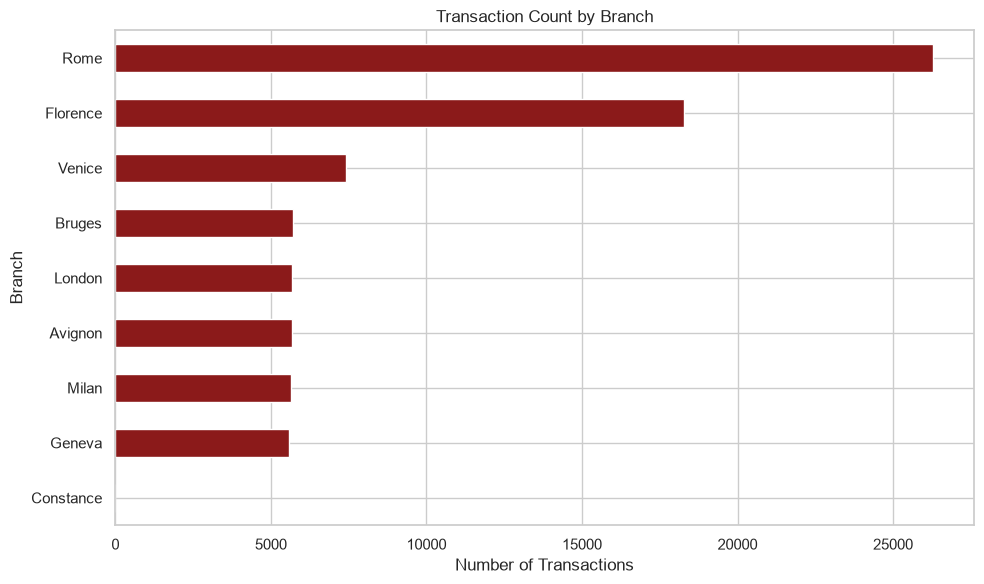

In [7]:
ax = branch_summary.sort_values("transaction_count").plot(
    kind="barh",
    y="transaction_count",
    legend=False,
    figsize=(10, 6),
    color="#8B1A1A",
)
ax.set_title("Transaction Count by Branch")
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Branch")
plt.tight_layout()
plt.show()

## 7. Transaction-Type Analysis

Compare transaction counts and percentages by category, then examine the transaction-type mix within each branch using count, percentage, and heatmap summaries.

In [8]:
type_summary_count = df.groupby("type").size().rename("transaction_count").to_frame()
type_summary_count["percentage"] = type_summary_count["transaction_count"] / total_transactions * 100
type_summary_count = type_summary_count.sort_values("transaction_count", ascending=False)

display(type_summary_count.style.format({
    "transaction_count": "{:,}",
    "percentage": "{:.2f}%",
}))

,transaction_count,percentage
type,,
deposit,"25,031",31.20%
operating_expense,"10,987",13.69%
war_financing,"10,568",13.17%
loan_repayment,"8,170",10.18%
loan_issuance,"7,478",9.32%
bill_of_exchange,"6,428",8.01%
withdrawal,"6,374",7.94%
alum_trade,"5,193",6.47%
ransom_payment,1,0.00%


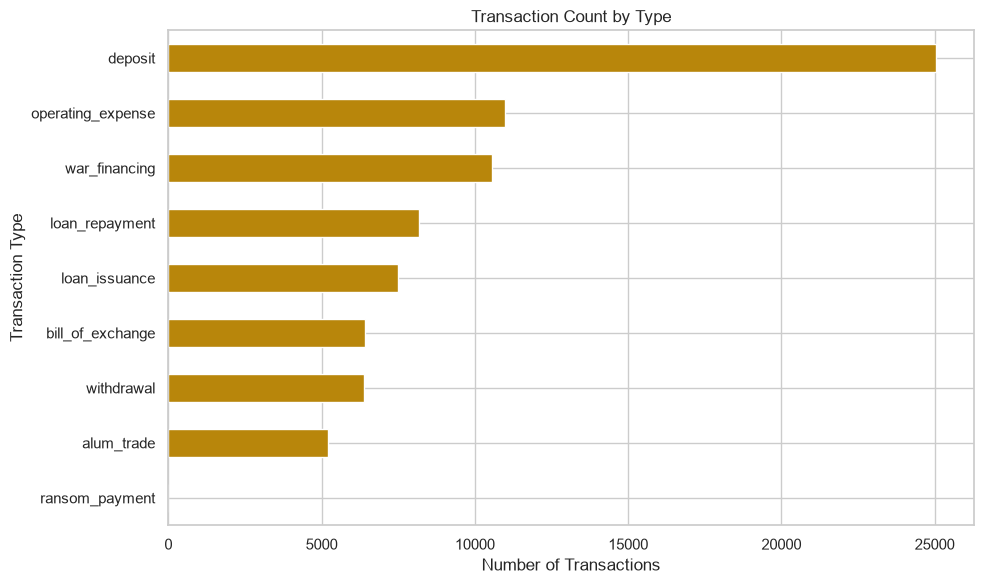

In [9]:
ax = type_summary_count.sort_values("transaction_count").plot(
    kind="barh",
    y="transaction_count",
    legend=False,
    figsize=(10, 6),
    color="#B8860B",
)
ax.set_title("Transaction Count by Type")
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Transaction Type")
plt.tight_layout()
plt.show()

In [10]:
branch_type_counts = pd.crosstab(df["branch"], df["type"])
branch_type_percentages = branch_type_counts.div(
    branch_type_counts.sum(axis=1), axis=0
) * 100

print("Counts")
display(branch_type_counts)
print("Within-branch percentages")
display(branch_type_percentages.style.format("{:.2f}%"))

Counts


type,alum_trade,bill_of_exchange,deposit,loan_issuance,loan_repayment,operating_expense,ransom_payment,war_financing,withdrawal
branch,,,,,,,,,
Avignon,0,791,796,903,1053,1314,0,0,806
Bruges,0,769,801,941,1061,1313,0,0,815
Constance,0,0,0,0,0,0,1,0,0
Florence,1774,818,788,921,1049,1576,0,10568,801
Geneva,0,837,745,880,1006,1339,0,0,768
London,0,819,776,942,982,1397,0,0,747
Milan,0,768,797,926,1000,1350,0,0,797
Rome,1708,861,19513,1005,1007,1342,0,0,852
Venice,1711,765,815,960,1012,1356,0,0,788


Within-branch percentages


type,alum_trade,bill_of_exchange,deposit,loan_issuance,loan_repayment,operating_expense,ransom_payment,war_financing,withdrawal
branch,,,,,,,,,
Avignon,0.00%,13.97%,14.06%,15.95%,18.59%,23.20%,0.00%,0.00%,14.23%
Bruges,0.00%,13.49%,14.05%,16.51%,18.61%,23.04%,0.00%,0.00%,14.30%
Constance,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%
Florence,9.70%,4.47%,4.31%,5.03%,5.73%,8.61%,0.00%,57.76%,4.38%
Geneva,0.00%,15.01%,13.36%,15.78%,18.04%,24.02%,0.00%,0.00%,13.78%
London,0.00%,14.46%,13.70%,16.63%,17.34%,24.67%,0.00%,0.00%,13.19%
Milan,0.00%,13.62%,14.14%,16.42%,17.74%,23.94%,0.00%,0.00%,14.14%
Rome,6.50%,3.28%,74.23%,3.82%,3.83%,5.10%,0.00%,0.00%,3.24%
Venice,23.10%,10.33%,11.00%,12.96%,13.66%,18.31%,0.00%,0.00%,10.64%


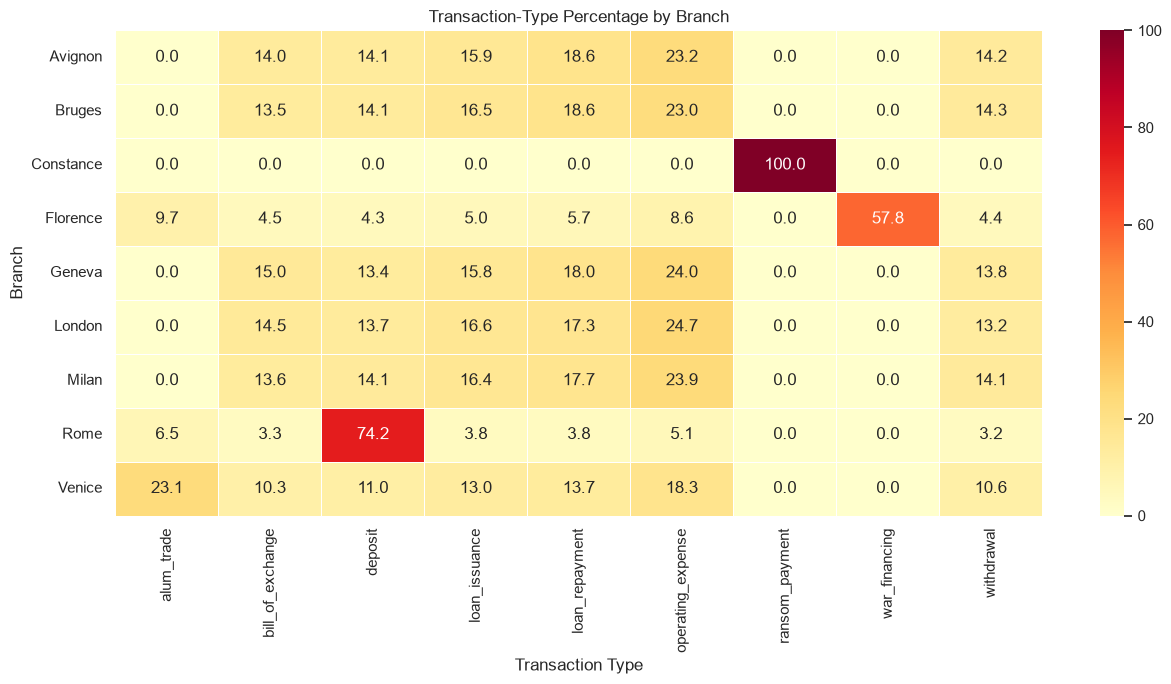

In [11]:
plt.figure(figsize=(13, 7))
sns.heatmap(
    branch_type_percentages,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
)
plt.title("Transaction-Type Percentage by Branch")
plt.xlabel("Transaction Type")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()

## 8. Time Analysis

Count transactions by year and visualize changes in Medici Bank activity from 1390 through 1440. Identify the highest- and lowest-activity years.

In [12]:
transactions_by_year = df.groupby("year").size().rename("transaction_count")

highest_year = transactions_by_year.idxmax()
lowest_year = transactions_by_year.idxmin()

display(transactions_by_year.to_frame())
print(f"Highest-activity year: {highest_year} ({transactions_by_year.max():,} transactions)")
print(f"Lowest-activity year: {lowest_year} ({transactions_by_year.min():,} transactions)")

,transaction_count
year,
1390,1632
1391,1520
1392,1614
1393,1519
1394,1565
1395,1606
1396,1554
1397,1547
1398,1602


Highest-activity year: 1424 (1,651 transactions)
Lowest-activity year: 1433 (1,479 transactions)


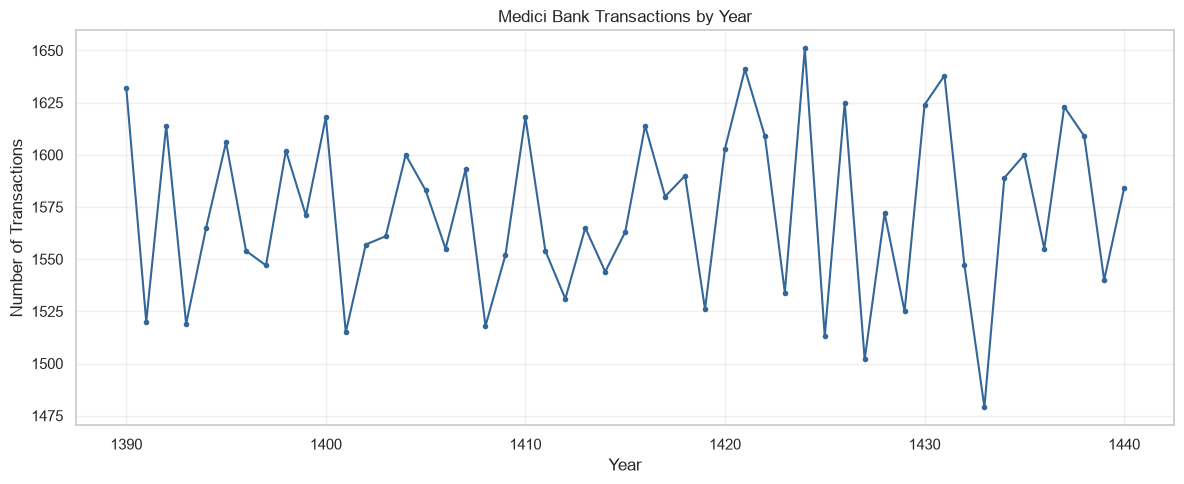

In [13]:
ax = transactions_by_year.plot(
    kind="line",
    figsize=(12, 5),
    marker="o",
    markersize=3,
    color="#336699",
)
ax.set_title("Medici Bank Transactions by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Transactions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Florin Volume Analysis

Calculate total and average transaction value, compare financial volume across branches and transaction types, and create a branch × transaction-type volume summary.

In [14]:
total_volume = df["debit_amount"].sum()
average_volume = df["debit_amount"].mean()

volume_by_branch = df.groupby("branch")["debit_amount"].sum().sort_values(ascending=False)
branch_volume_summary = volume_by_branch.rename("total_volume").to_frame()
branch_volume_summary["percentage_of_total"] = volume_by_branch / total_volume * 100

print(f"Total financial volume: {total_volume:,.2f} florins")
print(f"Average transaction value: {average_volume:,.2f} florins")
display(branch_volume_summary.style.format({
    "total_volume": "{:,.2f}",
    "percentage_of_total": "{:.2f}%",
}))

Total financial volume: 21,612,302,640.94 florins
Average transaction value: 269,379.32 florins


,total_volume,percentage_of_total
branch,,
Florence,"12,689,373,996.45",58.71%
Rome,"5,933,693,096.46",27.46%
Venice,"552,410,062.21",2.56%
Bruges,"508,955,001.35",2.35%
Avignon,"506,987,638.74",2.35%
Geneva,"481,535,499.29",2.23%
Milan,"470,585,850.98",2.18%
London,"468,726,495.46",2.17%
Constance,"35,000.00",0.00%


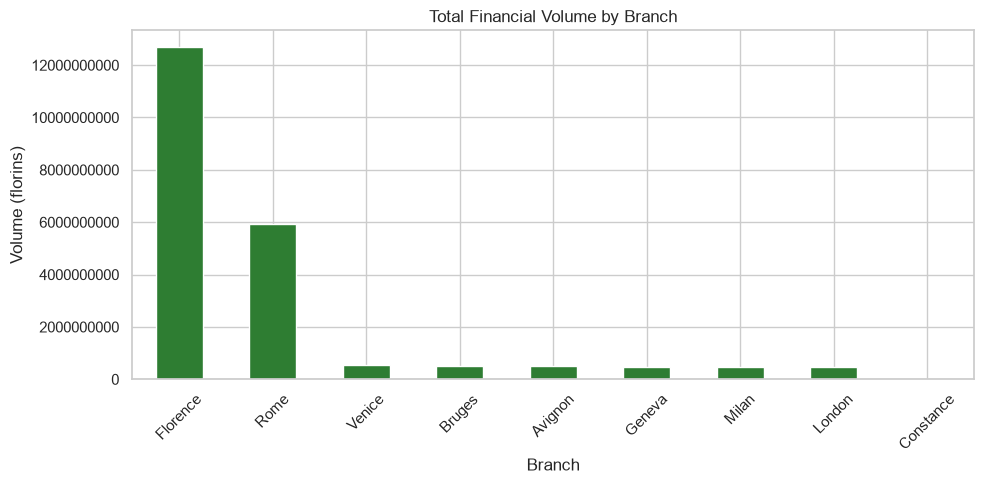

In [15]:
ax = volume_by_branch.plot(kind="bar", figsize=(10, 5), color="#2E7D32")
ax.set_title("Total Financial Volume by Branch")
ax.set_xlabel("Branch")
ax.set_ylabel("Volume (florins)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

In [16]:
type_financial_summary = (
    df.groupby("type")
      .agg(
          transaction_count=("type", "size"),
          total_volume=("debit_amount", "sum"),
          average_value=("debit_amount", "mean"),
      )
      .sort_values("total_volume", ascending=False)
)
type_financial_summary["percentage_of_total"] = (
    type_financial_summary["total_volume"] / total_volume * 100
)

display(type_financial_summary.style.format({
    "transaction_count": "{:,}",
    "total_volume": "{:,.2f}",
    "average_value": "{:,.2f}",
    "percentage_of_total": "{:.2f}%",
}))

,transaction_count,total_volume,average_value,percentage_of_total
type,,,,
war_financing,"10,568","12,107,772,332.19","1,145,701.39",56.02%
deposit,"25,031","5,924,145,611.16","236,672.35",27.41%
loan_issuance,"7,478","1,575,494,610.58","210,683.95",7.29%
bill_of_exchange,"6,428","732,406,422.35","113,940.02",3.39%
loan_repayment,"8,170","547,285,446.82","66,987.20",2.53%
withdrawal,"6,374","529,636,920.24","83,093.34",2.45%
alum_trade,"5,193","154,654,365.05","29,781.31",0.72%
operating_expense,"10,987","40,871,932.55","3,720.03",0.19%
ransom_payment,1,"35,000.00","35,000.00",0.00%


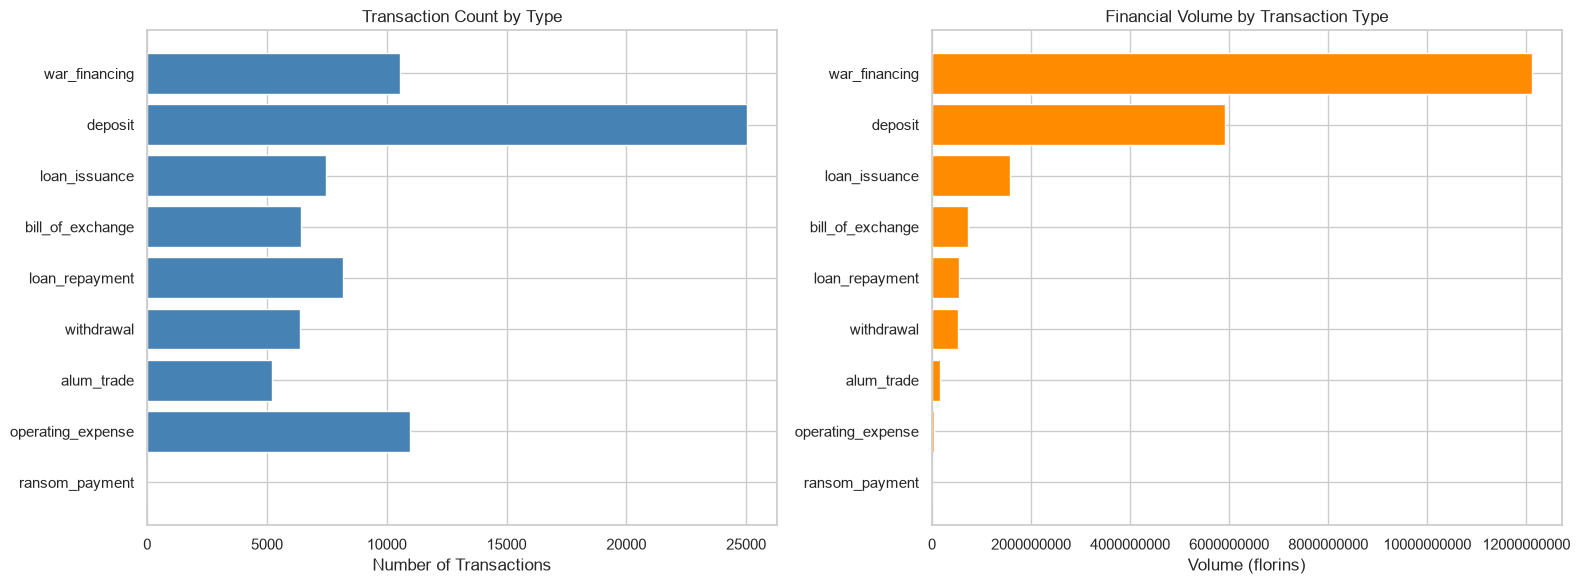

In [17]:
type_chart_data = type_financial_summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(type_chart_data["type"], type_chart_data["transaction_count"], color="steelblue")
axes[0].set_title("Transaction Count by Type")
axes[0].set_xlabel("Number of Transactions")
axes[0].invert_yaxis()

axes[1].barh(type_chart_data["type"], type_chart_data["total_volume"], color="darkorange")
axes[1].set_title("Financial Volume by Transaction Type")
axes[1].set_xlabel("Volume (florins)")
axes[1].ticklabel_format(style="plain", axis="x")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [18]:
branch_type_volume = pd.pivot_table(
    df,
    index="branch",
    columns="type",
    values="debit_amount",
    aggfunc="sum",
    fill_value=0,
)
branch_type_volume["Total"] = branch_type_volume.sum(axis=1)
branch_type_volume = branch_type_volume.sort_values("Total", ascending=False)

display(branch_type_volume.style.format("{:,.2f}"))

type,alum_trade,bill_of_exchange,deposit,loan_issuance,loan_repayment,operating_expense,ransom_payment,war_financing,withdrawal,Total
branch,,,,,,,,,,
Florence,"55,148,209.61","105,032,687.07","70,140,119.40","206,539,986.12","75,014,219.34","5,261,332.76",0.00,"12,107,772,332.19","64,465,109.96","12,689,373,996.45"
Rome,"46,859,956.43","91,054,548.25","5,442,471,256.87","216,595,479.85","64,537,214.41","4,584,441.84",0.00,0.00,"67,590,198.81","5,933,693,096.46"
Venice,"52,646,199.01","85,885,117.22","69,529,444.06","214,359,911.72","64,246,526.67","5,258,258.74",0.00,0.00,"60,484,604.79","552,410,062.21"
Bruges,0.00,"87,742,830.96","74,393,783.10","193,127,488.60","77,534,549.08","5,558,014.37",0.00,0.00,"70,598,335.24","508,955,001.35"
Avignon,0.00,"88,934,397.06","70,498,405.36","199,176,834.05","72,442,806.21","5,300,482.27",0.00,0.00,"70,634,713.79","506,987,638.74"
Geneva,0.00,"95,476,408.60","61,427,463.08","192,539,419.50","64,250,228.80","5,176,832.41",0.00,0.00,"62,665,146.90","481,535,499.29"
Milan,0.00,"84,550,065.82","67,390,829.03","177,717,017.07","66,071,372.51","4,752,346.19",0.00,0.00,"70,104,220.36","470,585,850.98"
London,0.00,"93,730,367.37","68,294,310.26","175,438,473.67","63,188,529.80","4,980,223.97",0.00,0.00,"63,094,590.39","468,726,495.46"
Constance,0.00,0.00,0.00,0.00,0.00,0.00,"35,000.00",0.00,0.00,"35,000.00"


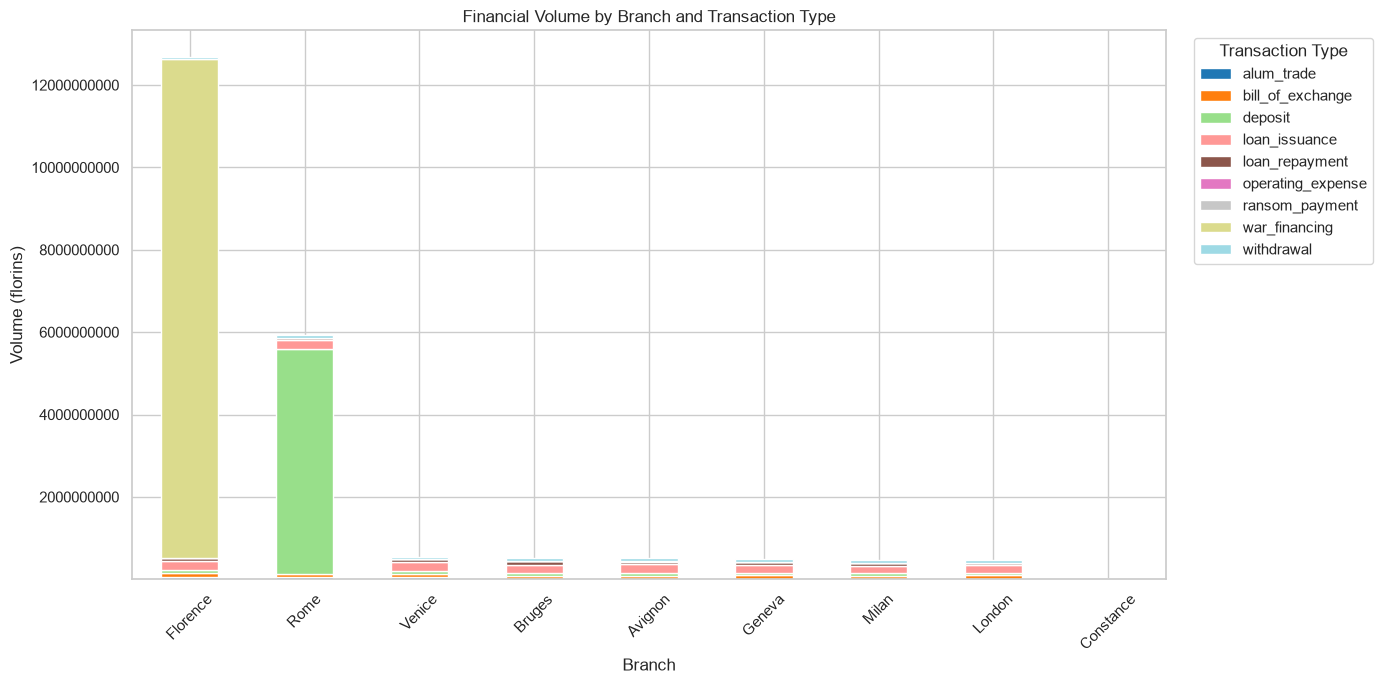

In [19]:
ax = branch_type_volume.drop(columns="Total").plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    colormap="tab20",
)
ax.set_title("Financial Volume by Branch and Transaction Type")
ax.set_xlabel("Branch")
ax.set_ylabel("Volume (florins)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Transaction Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Key Findings

Generate the principal Phase 1 findings directly from the calculated results so that the summary remains consistent if the source dataset changes.

In [20]:
highest_branch_count = branch_summary.index[0]
highest_branch_volume = volume_by_branch.index[0]
highest_type_count = type_summary_count.index[0]
highest_type_volume = type_financial_summary.index[0]

print("PHASE 1 SUMMARY")
print("-" * 70)
print(f"• The dataset contains {total_transactions:,} transactions from "
      f"{int(df['year'].min())} through {int(df['year'].max())}.")
print(f"• Duplicate IDs: {duplicate_ids:,}; exact duplicate rows: {duplicate_rows:,}.")
print(f"• Invalid or unbalanced accounting records: {len(unbalanced):,}.")
print(f"• Highest-activity branch: {highest_branch_count} "
      f"({branch_summary.iloc[0]['transaction_count']:,.0f} transactions).")
print(f"• Highest-volume branch: {highest_branch_volume} "
      f"({volume_by_branch.iloc[0]:,.2f} florins).")
print(f"• Most frequent transaction type: {highest_type_count} "
      f"({type_summary_count.iloc[0]['transaction_count']:,.0f} transactions).")
print(f"• Highest-volume transaction type: {highest_type_volume} "
      f"({type_financial_summary.iloc[0]['total_volume']:,.2f} florins).")
print(f"• Highest-activity year: {highest_year}; lowest-activity year: {lowest_year}.")
print(f"• Total financial volume: {total_volume:,.2f} florins.")

PHASE 1 SUMMARY
----------------------------------------------------------------------
• The dataset contains 80,230 transactions from 1390 through 1440.
• Duplicate IDs: 0; exact duplicate rows: 0.
• Invalid or unbalanced accounting records: 0.
• Highest-activity branch: Rome (26,288 transactions).
• Highest-volume branch: Florence (12,689,373,996.45 florins).
• Most frequent transaction type: deposit (25,031 transactions).
• Highest-volume transaction type: war_financing (12,107,772,332.19 florins).
• Highest-activity year: 1424; lowest-activity year: 1433.
• Total financial volume: 21,612,302,640.94 florins.


## 11. Phase 1 Conclusion

The integrated analysis confirms that the dataset can support the next phase of pipeline development:

- Dataset structure, columns, data types, and missing values have been documented.
- Duplicate records and secondary-credit consistency have been checked.
- Double-entry accounting integrity has been validated.
- Branch and transaction-type counts and percentages have been analyzed.
- Yearly trends and total florin volume have been examined.
- Volume by branch, transaction type, and branch × transaction type has been summarized.
- Tables, visualizations, and consolidated findings are included.

Phase 1 is complete after the team reviews these results and confirms that the integrated notebook runs successfully from beginning to end.